## Demo notebook

In this demo we will go through the basic functionalities of `RotOptSynth`.

In [1]:
import numpy as np
from scipy.stats import unitary_group
import pennylane as qml
import time
import rotoptsynth as ros
from tqdm.auto import tqdm
import matplotlib.pyplot as plt

In [2]:
# Pick some system size and generate a target with that size.
n = 5
N = 2**n
wires = list(range(n))
dim = 4**n
U = unitary_group.rvs(N, random_state=81512)

In [3]:
# We may first validate that the parameter-optimal QSD correctly impl
mat = qml.matrix(ros.po_qsd, wire_order=wires)(U, wires) # Compute matrix

In [4]:
# Next, we look at the gate counts produced by the PO-QSD
# We will use `qml.specs` for this, which operates on `qml.QNode`.

gate_set = {"CZ", "CNOT", "RY", "RZ", "GlobalPhase"}

@qml.decompose(gate_set=gate_set)
@qml.qnode(qml.device("default.qubit", wires=n))
def node(U):
    ros.po_qsd(U, wires)
    return qml.state()

In [5]:
gates = qml.specs(node)(U)["resources"].gate_types
num_rots = sum([val for key, val in gates.items() if key in ["RX", "RY", "RZ"]])
num_cnots = sum([val for key, val in gates.items() if key in ["CNOT", "CZ", "CY"]])
exp_num_rots = 4**n - 1
exp_num_cnots = int(4**n / 2 - 3/8*(n+2)*2**n + n -1)

print(f"PO-QSD has {num_rots} rotations. We expected {exp_num_rots}.", end=" ")
if num_rots == exp_num_rots:
    print('✅')
else:
    print('❌')

print(f"PO-QSD has {num_cnots} rotations. We expected {exp_num_cnots}.", end=" ")
if num_cnots == exp_num_cnots:
    print('✅')
else:
    print('❌')
    
print(f"Finally, we expect a single GlobalPhase: {'✅' if gates.get("GlobalPhase", None) == 1 else '❌'}\n")

PO-QSD has 1023 rotations. We expected 1023. ✅
PO-QSD has 432 rotations. We expected 432. ✅
Finally, we expect a single GlobalPhase: ✅



In [ ]:
# Let's also look at the CPU time:
times = []
ns = range(2, 7)
for n in tqdm(ns):
    reps = int(1000 / n**2)
    U = unitary_group.rvs(2**n, random_state=81512)
    wires = list(range(n))
    start = time.process_time()
    for _ in tqdm(range(reps)):
        ros.po_qsd(U, wires)
    times.append((time.process_time() - start)/reps)

  0%|          | 0/5 [00:00<?, ?it/s]

  0%|          | 0/250 [00:00<?, ?it/s]

  0%|          | 0/111 [00:00<?, ?it/s]

  0%|          | 0/62 [00:00<?, ?it/s]

  0%|          | 0/40 [00:00<?, ?it/s]

  0%|          | 0/27 [00:00<?, ?it/s]

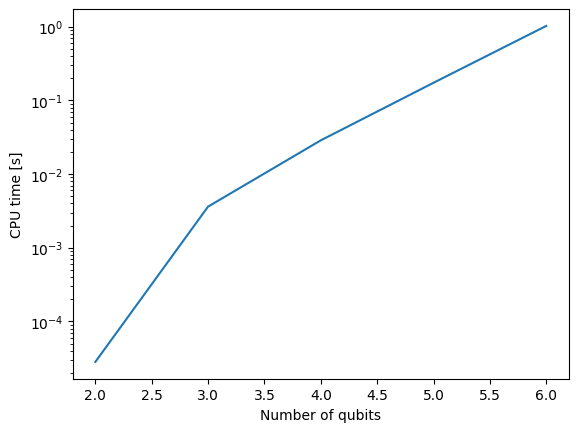

In [10]:
fig, ax = plt.subplots(1, 1)
ax.plot(ns, times)
ax.set_xlabel("Number of qubits")
ax.set_ylabel("CPU time [s]")
ax.set_yscale("log")

In [ ]:
import numpy as np                                                                                     
from scipy.stats import unitary_group                                                                  
import pennylane as qml                                                                                
import rotoptsynth as ros                                                                              
                                                                                                       
# Pick some system size and generate a target with that size.                                          
n = 3                                                                                                  
U = unitary_group.rvs(2**n, random_state=129)                                                          
wires = list(range(n))

In [ ]:
implemented_matrix = qml.matrix(ros.po_qsd, wire_order=wires)(U, wires)  
np.allclose(implemented_matrix, U)

In [7]:
# print(qml.draw(ros.po_qsd, show_matrices=False)(U, wires))